# Notebook 03 — Representaciones acumulativas normalizadas sobre embeddings Dialog2Flow 2.0

Esta notebook construye una variante acumulativa normalizada a partir de los embeddings Dialog2Flow y compara su comportamiento frente a los embeddings base mediante métricas de vecindad y un benchmark ANN reducido.

In [1]:
!pip install -q gdown faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 31.5 MB/s eta 0:00:00


## 1. Configuración del experimento

Se deja activo por defecto el modelo `dialog2flow-joint-bert-base`. Las otras opciones se mantienen comentadas para conservar compatibilidad con las corridas anteriores.

In [2]:
# EMBEDDING_EXPERIMENTO = "all-MiniLM-L6-v2"
# EMBEDDING_EXPERIMENTO = "all-mpnet-base-v2"
EMBEDDING_EXPERIMENTO = "dialog2flow-joint-bert-base"

RANDOM_STATE = 42

# Cantidad de consultas para el benchmark ANN reducido.
N_QUERIES = 10000

# Vecinos máximos para evaluar Recall@1, Recall@10 y Recall@100.
K_MAX = 100

# Repeticiones de búsqueda para estabilizar QPS.
N_REPETICIONES_BUSQUEDA = 3

# Parámetros reducidos para no repetir toda la Notebook 02.
NPROBE_VALUES = [1, 4, 16, 64]
EFSEARCH_VALUES = [16, 64, 128, 256]

# Tamaño de muestra para gráficos exploratorios.
N_MUESTRA_ANALISIS = 100000


## 2. Archivos de entrada

Usamos los archivos generados en las notebooks anteriores:

- `dialogs-2.0.pkl`: dataframe con los turnos.
- `ids.npy`: identificadores de filas.
- `embeddings_minilm.npy` o `embeddings_mpnet.npy`: embeddings estáticos.

In [3]:
# Ids de Google Drive

id_ids = "1hWC7nLvSboFHyykjr7VFAEmcvz8re1cY"

id_embeddings_mpnet = "1ndtChhGE3U5bkJ59NvuXhbX5Bgr7uOGe"
id_embeddings_minilm = "1imF_9lIGgGRJ7KQm-KhRPyinDUqPI_fW"
id_embeddings_dialog2flow = "1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW"

id_dataset = "1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb"


## 3. Descarga y carga de datos

Los embeddings se cargan con `mmap_mode="r"` para evitar cargar todo el archivo en RAM desde el inicio.

In [4]:
import os
import gc
import time
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss

if EMBEDDING_EXPERIMENTO == "all-MiniLM-L6-v2":
    id_embeddings = id_embeddings_minilm
    archivo_embeddings = "embeddings_minilm.npy"
    short_name = "minilm"

elif EMBEDDING_EXPERIMENTO == "all-mpnet-base-v2":
    id_embeddings = id_embeddings_mpnet
    archivo_embeddings = "embeddings_mpnet.npy"
    short_name = "mpnet"

elif EMBEDDING_EXPERIMENTO == "dialog2flow-joint-bert-base":
    id_embeddings = id_embeddings_dialog2flow
    archivo_embeddings = "embeddings_dialog2flow.npy"
    short_name = "dialog2flow"

else:
    raise ValueError(f"Modelo no reconocido: {EMBEDDING_EXPERIMENTO}")

archivos = {
    archivo_embeddings: id_embeddings,
    "ids.npy": id_ids,
    "dialogs-2.0.pkl": id_dataset,
}

for nombre_archivo, file_id in archivos.items():
    if not os.path.exists(nombre_archivo):
        print("Descargando:", nombre_archivo)
        gdown.download(f"https://drive.google.com/uc?id={file_id}", nombre_archivo, quiet=False)
    else:
        print("Ya existe:", nombre_archivo)

print("Experimento:", EMBEDDING_EXPERIMENTO)
print("Archivo de embeddings:", archivo_embeddings)
print("Nombre corto:", short_name)


Descargando: embeddings_dialog2flow.npy


Downloading...
From (original): https://drive.google.com/uc?id=1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW
From (redirected): https://drive.google.com/uc?id=1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW&confirm=t&uuid=4c6770f5-6f06-4047-8735-69c7703cd6dd
To: /content/embeddings_dialog2flow.npy
100%|██████████| 3.07G/3.07G [00:51<00:00, 59.1MB/s]


Descargando: ids.npy


Downloading...
From: https://drive.google.com/uc?id=1hWC7nLvSboFHyykjr7VFAEmcvz8re1cY
To: /content/ids.npy
100%|██████████| 8.00M/8.00M [00:00<00:00, 78.8MB/s]


Descargando: dialogs-2.0.pkl


Downloading...
From (original): https://drive.google.com/uc?id=1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb
From (redirected): https://drive.google.com/uc?id=1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb&confirm=t&uuid=0c5aec70-ef29-4297-a843-a716998d14e0
To: /content/dialogs-2.0.pkl
100%|██████████| 156M/156M [00:01<00:00, 123MB/s]

Experimento: dialog2flow-joint-bert-base
Archivo de embeddings: embeddings_dialog2flow.npy
Nombre corto: dialog2flow


In [5]:
embeddings = np.load(archivo_embeddings, mmap_mode="r")
ids = np.load("ids.npy")
df = pd.read_pickle("dialogs-2.0.pkl")

print("Embeddings:", embeddings.shape, embeddings.dtype)
print("Ids:", ids.shape)
print("Dataset:", df.shape)

Embeddings: (1000023, 768) float32
Ids: (1000023,)
Dataset: (1000023, 11)


## 4. Construcción de la representación acumulativa normalizada

En esta sección se construye una variante acumulativa normalizada a partir de la secuencia de embeddings de cada diálogo.

La actualización se aplica respetando el orden conversacional de cada diálogo (`dialogue_id`, `turn_id`) y reiniciando el estado al comienzo de cada conversación.

In [6]:
import torch

def cosine_np(a, b, eps=1e-12):
    return float(np.dot(a, b) / ((np.linalg.norm(a) + eps) * (np.linalg.norm(b) + eps)))

In [7]:
archivo_dynamic = f"accumulative_embeddings_{short_name}.npy"
archivo_similitud = f"similitud_static_accumulative_{short_name}.npy"
archivo_turn_pos = f"turn_position_{short_name}.npy"

n, d = embeddings.shape

# LayerNorm se define una sola vez usando la dimensionalidad de los embeddings.
# Se usa en CPU porque la operación es simple y evita depender del entorno GPU.
layer_norm = torch.nn.LayerNorm(d, elementwise_affine=False)
layer_norm.eval()

if not os.path.exists(archivo_dynamic):
    dynamic_embeddings = np.lib.format.open_memmap(
        archivo_dynamic,
        mode="w+",
        dtype="float32",
        shape=(n, d)
    )

    similitud_static_dynamic = np.lib.format.open_memmap(
        archivo_similitud,
        mode="w+",
        dtype="float32",
        shape=(n,)
    )

    turn_position = np.lib.format.open_memmap(
        archivo_turn_pos,
        mode="w+",
        dtype="int32",
        shape=(n,)
    )

    t0 = time.time()
    cantidad_dialogos = 0

    with torch.no_grad():
        for dialogue_id, grupo in df.groupby("dialogue_id", sort=False):
            grupo = grupo.sort_values("turn_id")
            indices_dialogo = grupo.index.to_numpy()

            h = torch.zeros(d, dtype=torch.float32)

            for idx in indices_dialogo:
                e_np = np.asarray(embeddings[idx], dtype="float32")
                e = torch.from_numpy(e_np.copy())

                h = layer_norm(h + e)
                h_np = h.numpy().astype("float32", copy=False)

                dynamic_embeddings[idx] = h_np
                similitud_static_dynamic[idx] = cosine_np(e_np, h_np)
                turn_position[idx] = int(df.loc[idx, "turn_id"])

            cantidad_dialogos += 1

            if cantidad_dialogos % 10000 == 0:
                print("Diálogos procesados:", cantidad_dialogos)

    dynamic_embeddings.flush()
    similitud_static_dynamic.flush()
    turn_position.flush()

    print("Representaciones acumulativas generadas en:", archivo_dynamic)
    print("Tiempo total:", round(time.time() - t0, 2), "segundos")

else:
    print("Ya existe el archivo:", archivo_dynamic)
    print("No se vuelve a generar.")


Diálogos procesados: 10000
Diálogos procesados: 20000
Diálogos procesados: 30000
Diálogos procesados: 40000
Diálogos procesados: 50000
Diálogos procesados: 60000
Diálogos procesados: 70000
Diálogos procesados: 80000
Diálogos procesados: 90000
Diálogos procesados: 100000
Representaciones acumulativas generadas en: accumulative_embeddings_dialog2flow.npy
Tiempo total: 174.75 segundos


In [8]:
dynamic_embeddings = np.load(archivo_dynamic, mmap_mode="r")
similitud_static_dynamic = np.load(archivo_similitud, mmap_mode="r")
turn_position = np.load(archivo_turn_pos, mmap_mode="r")

print("Dynamic embeddings:", dynamic_embeddings.shape, dynamic_embeddings.dtype)
print("Similitudes:", similitud_static_dynamic.shape)
print("Posiciones:", turn_position.shape)

Dynamic embeddings: (1000023, 768) float32
Similitudes: (1000023,)
Posiciones: (1000023,)


## 5. Análisis base vs acumulativo

In [9]:
np.random.seed(RANDOM_STATE)

muestra_size = min(N_MUESTRA_ANALISIS, len(similitud_static_dynamic))
muestra_idx = np.random.choice(len(similitud_static_dynamic), size=muestra_size, replace=False)

sim_muestra = np.asarray(similitud_static_dynamic[muestra_idx])
turn_muestra = np.asarray(turn_position[muestra_idx])

print("Similitud promedio:", sim_muestra.mean())
print("Similitud mediana:", np.median(sim_muestra))
print("Similitud mínima:", sim_muestra.min())
print("Similitud máxima:", sim_muestra.max())

Similitud promedio: 0.72685987
Similitud mediana: 0.70241046
Similitud mínima: 0.41638508
Similitud máxima: 0.9997142


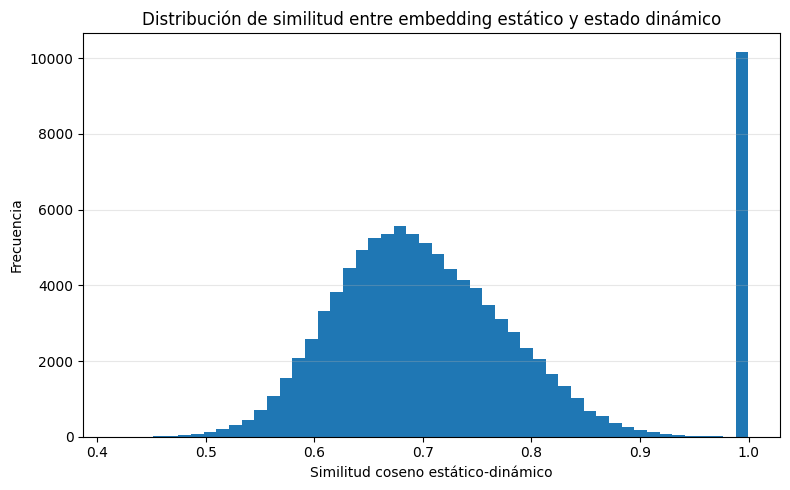

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(sim_muestra, bins=50)
plt.xlabel("Similitud coseno estático-dinámico")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitud entre embedding estático y estado dinámico")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

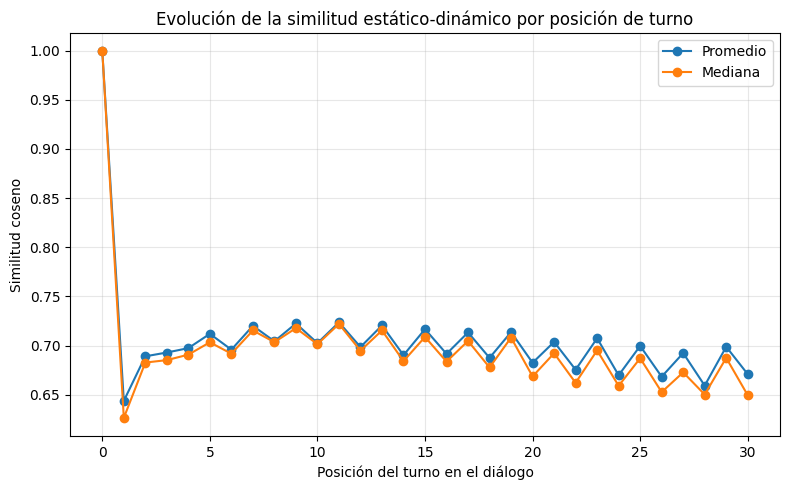

In [11]:
df_sim = pd.DataFrame({
    "turn_position": turn_muestra,
    "similarity": sim_muestra
})

df_turn = (
    df_sim[df_sim["turn_position"] <= 30]
    .groupby("turn_position", as_index=False)
    .agg(
        similarity_mean=("similarity", "mean"),
        similarity_median=("similarity", "median")
    )
)

plt.figure(figsize=(8, 5))
plt.plot(df_turn["turn_position"], df_turn["similarity_mean"], marker="o", label="Promedio")
plt.plot(df_turn["turn_position"], df_turn["similarity_median"], marker="o", label="Mediana")
plt.xlabel("Posición del turno en el diálogo")
plt.ylabel("Similitud coseno")
plt.title("Evolución de la similitud estático-dinámico por posición de turno")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cantidad de diálogos graficados: 50


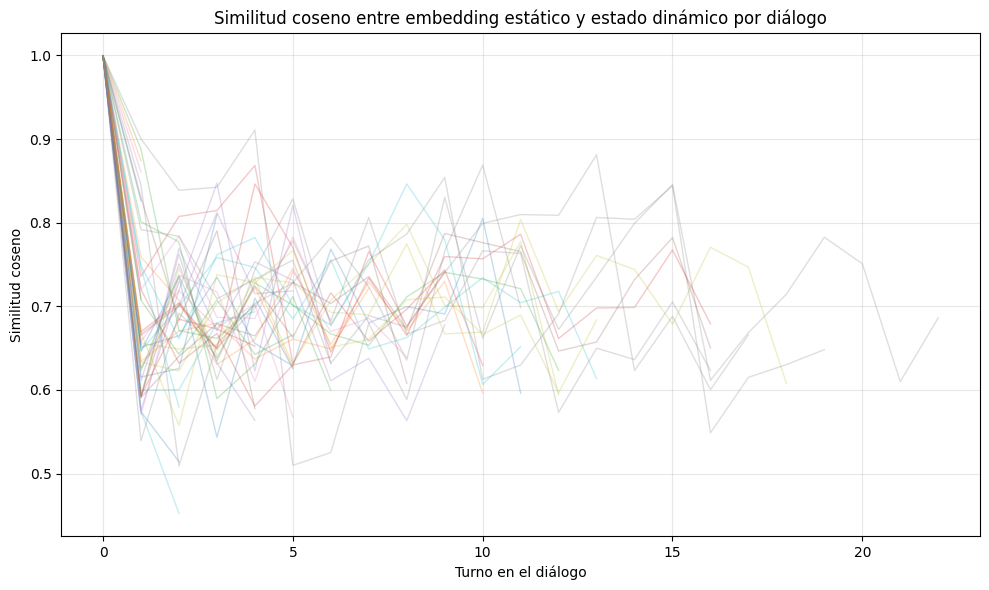

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cantidad de diálogos a graficar.
# Si es None, se grafican todos.
N_DIALOGOS_GRAFICO = 50
RANDOM_STATE_GRAFICO = 42

# Dataframe auxiliar con la información necesaria para graficar
df_plot = df[["dialogue_id", "turn_id"]].copy()
df_plot["cosine_similarity"] = np.asarray(similitud_static_dynamic)

# Selección de diálogos
dialogos_disponibles = df_plot["dialogue_id"].unique()

if N_DIALOGOS_GRAFICO is None or N_DIALOGOS_GRAFICO >= len(dialogos_disponibles):
    dialogos_muestra = dialogos_disponibles
else:
    np.random.seed(RANDOM_STATE_GRAFICO)
    dialogos_muestra = np.random.choice(
        dialogos_disponibles,
        size=N_DIALOGOS_GRAFICO,
        replace=False
    )

df_plot_muestra = df_plot[df_plot["dialogue_id"].isin(dialogos_muestra)]

print("Cantidad de diálogos graficados:", len(dialogos_muestra))

plt.figure(figsize=(10, 6))

for dialog_id, grupo in df_plot_muestra.groupby("dialogue_id"):
    grupo = grupo.sort_values("turn_id")
    plt.plot(
        grupo["turn_id"],
        grupo["cosine_similarity"],
        alpha=0.25,
        linewidth=1
    )

plt.xlabel("Turno en el diálogo")
plt.ylabel("Similitud coseno")
plt.title("Similitud coseno entre embedding estático y estado dinámico por diálogo")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Superposición de vecindades exactas

In [13]:
def recall_at_k(I_exact, I_test, k):
    recalls = []

    for exact, test in zip(I_exact[:, :k], I_test[:, :k]):
        recalls.append(len(set(exact).intersection(set(test))) / k)

    return float(np.mean(recalls))


def preparar_split(n_total, n_queries, random_state):
    np.random.seed(random_state)

    query_idx = np.random.choice(
        n_total,
        size=n_queries,
        replace=False
    )

    mask = np.ones(n_total, dtype=bool)
    mask[query_idx] = False
    index_idx = np.where(mask)[0]

    return index_idx, query_idx

In [14]:
index_idx, query_idx = preparar_split(
    n_total=embeddings.shape[0],
    n_queries=N_QUERIES,
    random_state=RANDOM_STATE
)

print("Vectores indexados:", index_idx.shape)
print("Vectores de consulta:", query_idx.shape)

Vectores indexados: (990023,)
Vectores de consulta: (10000,)


In [15]:
def obtener_vecinos_flat(matriz, index_idx, query_idx, k):
    index_vectors = np.asarray(matriz[index_idx], dtype="float32")
    query_vectors = np.asarray(matriz[query_idx], dtype="float32")

    faiss.normalize_L2(index_vectors)
    faiss.normalize_L2(query_vectors)

    d = index_vectors.shape[1]

    index_flat = faiss.IndexFlatL2(d)
    index_flat.add(index_vectors)

    D, I = index_flat.search(query_vectors, k)

    del index_flat
    del D
    del index_vectors
    del query_vectors
    gc.collect()

    return I

In [16]:
I_static_exact = obtener_vecinos_flat(embeddings, index_idx, query_idx, K_MAX)
I_dynamic_exact = obtener_vecinos_flat(dynamic_embeddings, index_idx, query_idx, K_MAX)

overlap_1 = recall_at_k(I_static_exact, I_dynamic_exact, 1)
overlap_10 = recall_at_k(I_static_exact, I_dynamic_exact, 10)
overlap_100 = recall_at_k(I_static_exact, I_dynamic_exact, 100)

print("Superposición vecinos exactos estático vs dinámico")
print("Overlap@1:", overlap_1)
print("Overlap@10:", overlap_10)
print("Overlap@100:", overlap_100)

Superposición vecinos exactos estático vs dinámico
Overlap@1: 0.2956
Overlap@10: 0.17503000000000002
Overlap@100: 0.151541


## 7. Benchmark ANN reducido: embeddings base vs representación acumulativa

In [17]:
def medir_busqueda(index, query_vectors, k, n_repeticiones=3):
    # Warm-up para estabilizar medición.
    index.search(query_vectors[:min(100, len(query_vectors))], k)

    tiempos = []

    for _ in range(n_repeticiones):
        t0 = time.time()
        D, I = index.search(query_vectors, k)
        t1 = time.time()
        tiempos.append(t1 - t0)

    search_time_s = float(np.median(tiempos))
    qps = len(query_vectors) / search_time_s

    return D, I, search_time_s, qps


def estimar_memoria_flat_mb(n, d):
    return n * d * 4 / (1024 ** 2)


def estimar_memoria_hnsw_mb(n, d, M):
    vectores = n * d * 4
    enlaces = n * M * 4
    return (vectores + enlaces) / (1024 ** 2)


def preparar_vectores_representacion(matriz, index_idx, query_idx):
    index_vectors = np.asarray(matriz[index_idx], dtype="float32")
    query_vectors = np.asarray(matriz[query_idx], dtype="float32")

    faiss.normalize_L2(index_vectors)
    faiss.normalize_L2(query_vectors)

    return index_vectors, query_vectors

In [18]:
def benchmark_representacion(nombre_rep, matriz, index_idx, query_idx):
    resultados = []

    print("Preparando representación:", nombre_rep)

    index_vectors, query_vectors = preparar_vectores_representacion(matriz, index_idx, query_idx)

    n_index, d = index_vectors.shape

    # Ground truth exacto
    print("Calculando ground truth FlatL2...")
    index_flat = faiss.IndexFlatL2(d)
    index_flat.add(index_vectors)

    D_exact, I_exact, search_time_flat, qps_flat = medir_busqueda(
        index_flat,
        query_vectors,
        K_MAX,
        N_REPETICIONES_BUSQUEDA
    )

    resultados.append({
        "representation": nombre_rep,
        "index_type": "FlatL2",
        "params": {},
        "recall@1": 1.0,
        "recall@10": 1.0,
        "recall@100": 1.0,
        "qps": qps_flat,
        "search_time_s": search_time_flat,
        "build_time_s": None,
        "memory_mb": estimar_memoria_flat_mb(n_index, d),
        "num_index_vectors": n_index,
        "num_queries": len(query_vectors),
        "dimension": d,
        "embedding_model": EMBEDDING_EXPERIMENTO,
    })

    del index_flat
    del D_exact
    gc.collect()

    # IVF
    nlist = 4096
    IVF_TRAIN_SIZE = min(100000, n_index)

    np.random.seed(RANDOM_STATE)
    train_idx = np.random.choice(n_index, size=IVF_TRAIN_SIZE, replace=False)
    train_vectors = index_vectors[train_idx]

    quantizer = faiss.IndexFlatL2(d)
    index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)

    print("Entrenando IVF...")
    t0 = time.time()
    index_ivf.train(train_vectors)
    index_ivf.add(index_vectors)
    build_time_ivf = time.time() - t0

    for nprobe in NPROBE_VALUES:
        index_ivf.nprobe = nprobe

        D_ivf, I_ivf, search_time_s, qps = medir_busqueda(
            index_ivf,
            query_vectors,
            K_MAX,
            N_REPETICIONES_BUSQUEDA
        )

        resultados.append({
            "representation": nombre_rep,
            "index_type": "IVF",
            "params": {"nlist": nlist, "nprobe": nprobe},
            "nlist": nlist,
            "nprobe": nprobe,
            "recall@1": recall_at_k(I_exact, I_ivf, 1),
            "recall@10": recall_at_k(I_exact, I_ivf, 10),
            "recall@100": recall_at_k(I_exact, I_ivf, 100),
            "qps": qps,
            "search_time_s": search_time_s,
            "build_time_s": build_time_ivf,
            "memory_mb": estimar_memoria_flat_mb(n_index, d),
            "num_index_vectors": n_index,
            "num_queries": len(query_vectors),
            "dimension": d,
            "embedding_model": EMBEDDING_EXPERIMENTO,
        })

    del index_ivf
    del quantizer
    del train_vectors
    del train_idx
    del D_ivf
    del I_ivf
    gc.collect()

    # HNSW
    M = 32
    ef_construction = 200

    print("Construyendo HNSW...")

    t0 = time.time()
    index_hnsw = faiss.IndexHNSWFlat(d, M)
    index_hnsw.hnsw.efConstruction = ef_construction
    index_hnsw.add(index_vectors)
    build_time_hnsw = time.time() - t0

    for efSearch in EFSEARCH_VALUES:
        index_hnsw.hnsw.efSearch = efSearch

        D_hnsw, I_hnsw, search_time_s, qps = medir_busqueda(
            index_hnsw,
            query_vectors,
            K_MAX,
            N_REPETICIONES_BUSQUEDA
        )

        resultados.append({
            "representation": nombre_rep,
            "index_type": "HNSW",
            "params": {"M": M, "efConstruction": ef_construction, "efSearch": efSearch},
            "M": M,
            "efConstruction": ef_construction,
            "efSearch": efSearch,
            "recall@1": recall_at_k(I_exact, I_hnsw, 1),
            "recall@10": recall_at_k(I_exact, I_hnsw, 10),
            "recall@100": recall_at_k(I_exact, I_hnsw, 100),
            "qps": qps,
            "search_time_s": search_time_s,
            "build_time_s": build_time_hnsw,
            "memory_mb": estimar_memoria_hnsw_mb(n_index, d, M),
            "num_index_vectors": n_index,
            "num_queries": len(query_vectors),
            "dimension": d,
            "embedding_model": EMBEDDING_EXPERIMENTO,
        })

    del index_hnsw
    del D_hnsw
    del I_hnsw
    del index_vectors
    del query_vectors
    del I_exact
    gc.collect()

    return pd.DataFrame(resultados)

In [19]:
df_results_static = benchmark_representacion(
    nombre_rep="base_embeddings",
    matriz=embeddings,
    index_idx=index_idx,
    query_idx=query_idx
)

df_results_static

Preparando representación: base_embeddings
Calculando ground truth FlatL2...
Entrenando IVF...
Construyendo HNSW...


,representation,index_type,params,recall@1,recall@10,recall@100,qps,search_time_s,build_time_s,memory_mb,num_index_vectors,num_queries,dimension,embedding_model,nlist,nprobe,M,efConstruction,efSearch
0,base_embeddings,FlatL2,{},1.0000,1.00000,1.000000,36.796531,271.764750,NaN,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,NaN,NaN,NaN
1,base_embeddings,IVF,"{'nlist': 4096, 'nprobe': 1}",0.6324,0.74512,0.687730,4717.105522,2.119944,235.611958,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,1.0,NaN,NaN,NaN
2,base_embeddings,IVF,"{'nlist': 4096, 'nprobe': 4}",0.6758,0.85978,0.902509,2113.357969,4.731806,235.611958,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,4.0,NaN,NaN,NaN
3,base_embeddings,IVF,"{'nlist': 4096, 'nprobe': 16}",0.6840,0.87848,0.946641,676.956630,14.771995,235.611958,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,16.0,NaN,NaN,NaN
4,base_embeddings,IVF,"{'nlist': 4096, 'nprobe': 64}",0.6856,0.88143,0.953621,195.796133,51.073532,235.611958,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,64.0,NaN,NaN,NaN
5,base_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 16}",0.6599,0.85044,0.614618,6159.782940,1.623434,983.051657,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,16.0
6,base_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 64}",0.6726,0.86512,0.895965,2576.679534,3.880964,983.051657,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,64.0
7,base_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 128}",0.6760,0.86920,0.935989,1759.058052,5.684861,983.051657,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,128.0
8,base_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 256}",0.6778,0.87067,0.939178,948.353590,10.544590,983.051657,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,256.0


In [20]:
df_results_dynamic = benchmark_representacion(
    nombre_rep="accumulative_normalized_embeddings",
    matriz=dynamic_embeddings,
    index_idx=index_idx,
    query_idx=query_idx
)

df_results_dynamic

Preparando representación: accumulative_normalized_embeddings
Calculando ground truth FlatL2...
Entrenando IVF...
Construyendo HNSW...


,representation,index_type,params,recall@1,recall@10,recall@100,qps,search_time_s,build_time_s,memory_mb,num_index_vectors,num_queries,dimension,embedding_model,nlist,nprobe,M,efConstruction,efSearch
0,accumulative_normalized_embeddings,FlatL2,{},1.0000,1.00000,1.000000,36.532073,273.732070,NaN,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,NaN,NaN,NaN
1,accumulative_normalized_embeddings,IVF,"{'nlist': 4096, 'nprobe': 1}",0.6238,0.54094,0.466733,4637.535018,2.156318,230.121899,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,1.0,NaN,NaN,NaN
2,accumulative_normalized_embeddings,IVF,"{'nlist': 4096, 'nprobe': 4}",0.8139,0.78548,0.778793,1864.412784,5.363619,230.121899,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,4.0,NaN,NaN,NaN
3,accumulative_normalized_embeddings,IVF,"{'nlist': 4096, 'nprobe': 16}",0.8944,0.91990,0.939751,621.968411,16.077987,230.121899,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,16.0,NaN,NaN,NaN
4,accumulative_normalized_embeddings,IVF,"{'nlist': 4096, 'nprobe': 64}",0.9110,0.97189,0.988011,184.199088,54.289085,230.121899,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,64.0,NaN,NaN,NaN
5,accumulative_normalized_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 16}",0.8662,0.95241,0.679513,5276.106943,1.895337,1413.550493,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,16.0
6,accumulative_normalized_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 64}",0.8998,0.97580,0.959855,1648.367407,6.066609,1413.550493,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,64.0
7,accumulative_normalized_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 128}",0.9070,0.97911,0.992543,1039.891915,9.616384,1413.550493,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,128.0
8,accumulative_normalized_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 256}",0.9103,0.98112,0.996036,627.289041,15.941614,1413.550493,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,256.0


In [21]:
df_results = pd.concat([df_results_static, df_results_dynamic], ignore_index=True)

df_results

,representation,index_type,params,recall@1,recall@10,recall@100,qps,search_time_s,build_time_s,memory_mb,num_index_vectors,num_queries,dimension,embedding_model,nlist,nprobe,M,efConstruction,efSearch
0,base_embeddings,FlatL2,{},1.0000,1.00000,1.000000,36.796531,271.764750,NaN,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,NaN,NaN,NaN
1,base_embeddings,IVF,"{'nlist': 4096, 'nprobe': 1}",0.6324,0.74512,0.687730,4717.105522,2.119944,235.611958,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,1.0,NaN,NaN,NaN
2,base_embeddings,IVF,"{'nlist': 4096, 'nprobe': 4}",0.6758,0.85978,0.902509,2113.357969,4.731806,235.611958,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,4.0,NaN,NaN,NaN
3,base_embeddings,IVF,"{'nlist': 4096, 'nprobe': 16}",0.6840,0.87848,0.946641,676.956630,14.771995,235.611958,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,16.0,NaN,NaN,NaN
4,base_embeddings,IVF,"{'nlist': 4096, 'nprobe': 64}",0.6856,0.88143,0.953621,195.796133,51.073532,235.611958,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,4096.0,64.0,NaN,NaN,NaN
5,base_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 16}",0.6599,0.85044,0.614618,6159.782940,1.623434,983.051657,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,16.0
6,base_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 64}",0.6726,0.86512,0.895965,2576.679534,3.880964,983.051657,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,64.0
7,base_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 128}",0.6760,0.86920,0.935989,1759.058052,5.684861,983.051657,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,128.0
8,base_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 256}",0.6778,0.87067,0.939178,948.353590,10.544590,983.051657,3021.310425,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,32.0,200.0,256.0
9,accumulative_normalized_embeddings,FlatL2,{},1.0000,1.00000,1.000000,36.532073,273.732070,NaN,2900.458008,990023,10000,768,dialog2flow-joint-bert-base,NaN,NaN,NaN,NaN,NaN


## 8. Comparación de curvas Recall vs QPS

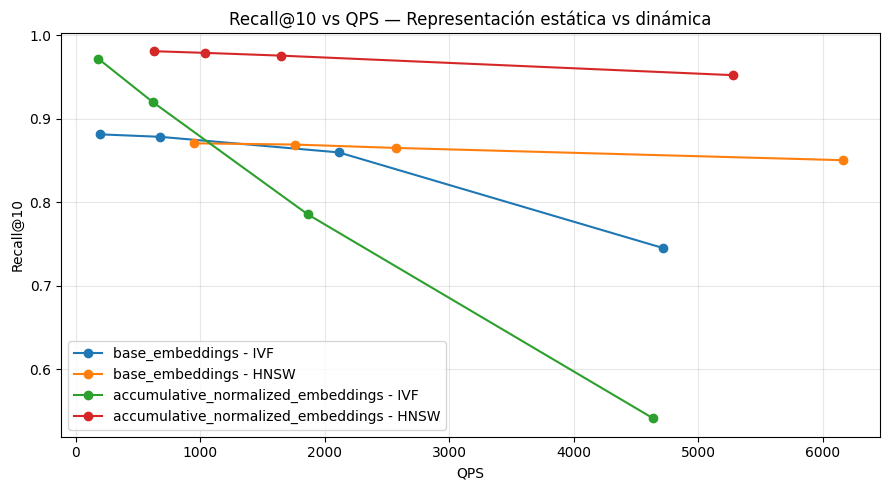

In [22]:
plt.figure(figsize=(9, 5))

for representation in df_results["representation"].unique():
    for index_type in ["IVF", "HNSW"]:
        subset = df_results[
            (df_results["representation"] == representation) &
            (df_results["index_type"] == index_type)
        ].sort_values("qps")

        label = f"{representation} - {index_type}"
        plt.plot(subset["qps"], subset["recall@10"], marker="o", label=label)

plt.xlabel("QPS")
plt.ylabel("Recall@10")
plt.title("Recall@10 vs QPS — Representación estática vs dinámica")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

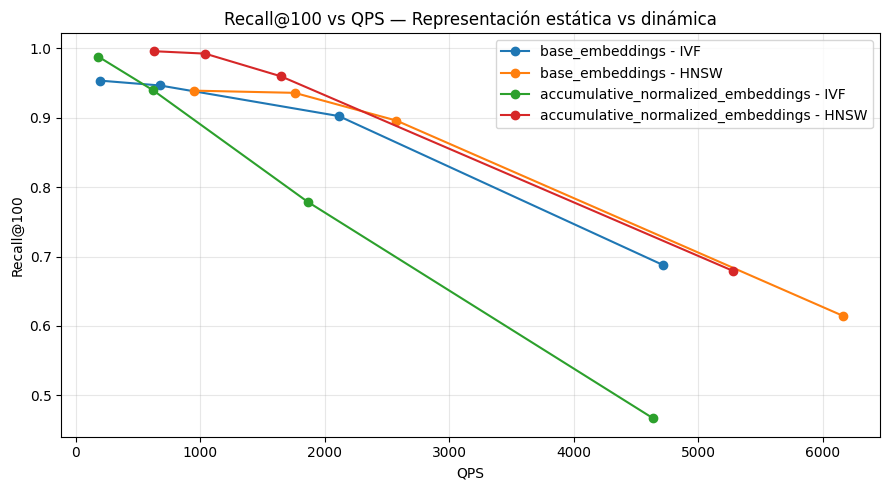

In [23]:
plt.figure(figsize=(9, 5))

for representation in df_results["representation"].unique():
    for index_type in ["IVF", "HNSW"]:
        subset = df_results[
            (df_results["representation"] == representation) &
            (df_results["index_type"] == index_type)
        ].sort_values("qps")

        label = f"{representation} - {index_type}"
        plt.plot(subset["qps"], subset["recall@100"], marker="o", label=label)

plt.xlabel("QPS")
plt.ylabel("Recall@100")
plt.title("Recall@100 vs QPS — Representación estática vs dinámica")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Diagnóstico por parámetro

Estas tablas ayudan a interpretar si los índices se comportan de forma coherente al variar `nprobe` o `efSearch`.

In [24]:
df_results[
    df_results["index_type"] == "IVF"
][
    ["representation", "nprobe", "qps", "recall@10", "recall@100"]
].sort_values(["representation", "nprobe"])

,representation,nprobe,qps,recall@10,recall@100
10,accumulative_normalized_embeddings,1.0,4637.535018,0.54094,0.466733
11,accumulative_normalized_embeddings,4.0,1864.412784,0.78548,0.778793
12,accumulative_normalized_embeddings,16.0,621.968411,0.91990,0.939751
13,accumulative_normalized_embeddings,64.0,184.199088,0.97189,0.988011
1,base_embeddings,1.0,4717.105522,0.74512,0.687730
2,base_embeddings,4.0,2113.357969,0.85978,0.902509
3,base_embeddings,16.0,676.956630,0.87848,0.946641
4,base_embeddings,64.0,195.796133,0.88143,0.953621


In [25]:
df_results[
    df_results["index_type"] == "HNSW"
][
    ["representation", "efSearch", "qps", "recall@10", "recall@100"]
].sort_values(["representation", "efSearch"])

,representation,efSearch,qps,recall@10,recall@100
14,accumulative_normalized_embeddings,16.0,5276.106943,0.95241,0.679513
15,accumulative_normalized_embeddings,64.0,1648.367407,0.97580,0.959855
16,accumulative_normalized_embeddings,128.0,1039.891915,0.97911,0.992543
17,accumulative_normalized_embeddings,256.0,627.289041,0.98112,0.996036
5,base_embeddings,16.0,6159.782940,0.85044,0.614618
6,base_embeddings,64.0,2576.679534,0.86512,0.895965
7,base_embeddings,128.0,1759.058052,0.86920,0.935989
8,base_embeddings,256.0,948.353590,0.87067,0.939178


## 10. Visualización UMAP de embeddings base y representaciones acumulativas

In [26]:
!pip install -q umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


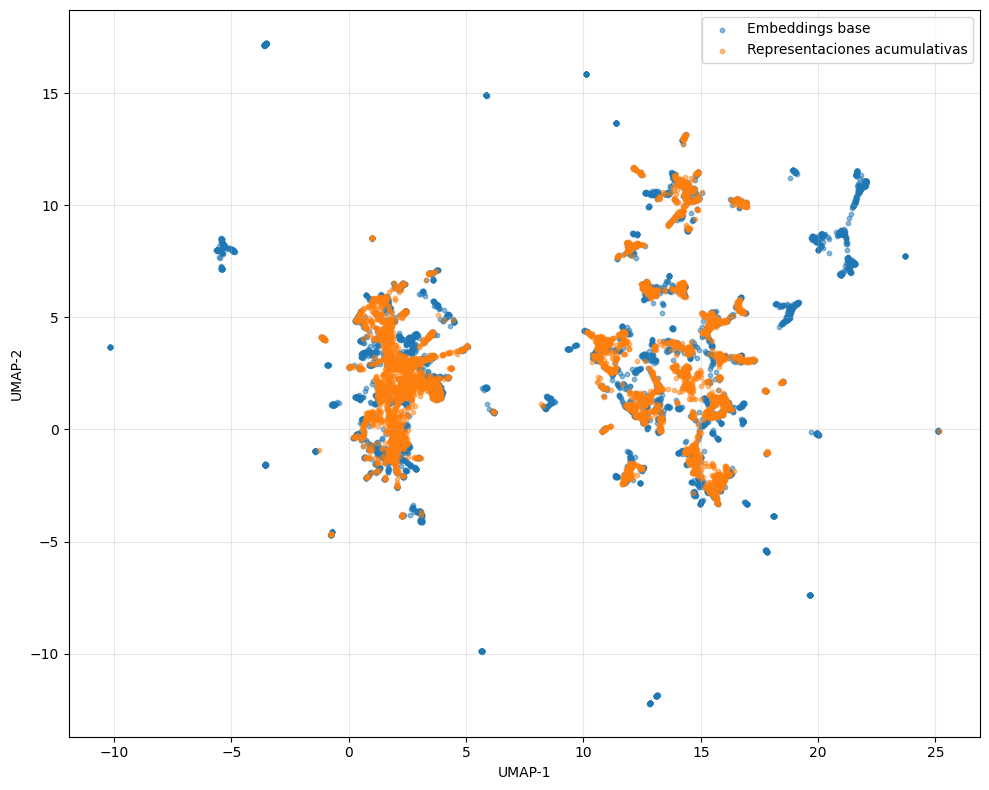

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import umap

# Muestra para UMAP
N_UMAP = 5000
RANDOM_STATE_UMAP = 42

np.random.seed(RANDOM_STATE_UMAP)

umap_idx = np.random.choice(
    np.arange(dynamic_embeddings.shape[0]),
    size=min(N_UMAP, dynamic_embeddings.shape[0]),
    replace=False
)

static_umap = np.asarray(embeddings[umap_idx], dtype="float32")
dynamic_umap = np.asarray(dynamic_embeddings[umap_idx], dtype="float32")

# Unimos ambas representaciones
X_umap = np.vstack([static_umap, dynamic_umap])
labels_umap = np.array(
    ["Embeddings base"] * len(static_umap) +
    ["Representaciones acumulativas"] * len(dynamic_umap)
)

# Reducimos dimensionalidad
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords_umap = reducer.fit_transform(X_umap)

# Máscara
mask_static = labels_umap == "Embeddings base"
mask_dynamic = labels_umap == "Representaciones acumulativas"

# Gráfico
plt.figure(figsize=(10, 8))
plt.scatter(
    coords_umap[mask_static, 0],
    coords_umap[mask_static, 1],
    s=10,
    alpha=0.5,
    label="Embeddings base"
)
plt.scatter(
    coords_umap[mask_dynamic, 0],
    coords_umap[mask_dynamic, 1],
    s=10,
    alpha=0.5,
    label="Representaciones acumulativas"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Guardado de resultados

Guardamos:

- la matriz de estados dinámicos;
- las similitudes estático-dinámico;
- los resultados del benchmark reducido.

La fecha-hora se guarda usando hora argentina para facilitar la trazabilidad de corridas.

In [29]:
from google.colab import drive
from datetime import datetime
from zoneinfo import ZoneInfo
import shutil

drive.mount("/content/drive")

carpeta_resultados = "/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados"
carpeta_data = "/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0"

os.makedirs(carpeta_resultados, exist_ok=True)
os.makedirs(carpeta_data, exist_ok=True)

fecha_hora_arg = datetime.now(ZoneInfo("America/Argentina/Buenos_Aires")).strftime("%Y%m%d_%H%M%S")

modelo = EMBEDDING_EXPERIMENTO.replace("/", "_").replace("-", "_")

archivo_resultados = f"resultados_dynamic_states_{modelo}_{fecha_hora_arg}_ARG.csv"
ruta_resultados = os.path.join(carpeta_resultados, archivo_resultados)

df_export = df_results.copy()
df_export["params"] = df_export["params"].astype(str)
df_export.to_csv(ruta_resultados, index=False)

print("Resultados guardados en:")
print(ruta_resultados)

# Copiamos los estados dinámicos y las métricas auxiliares a Drive.
for archivo in [archivo_dynamic, archivo_similitud, archivo_turn_pos]:
    shutil.copy(archivo, os.path.join(carpeta_data, archivo))
    print("Copiado:", os.path.join(carpeta_data, archivo))

Mounted at /content/drive
Resultados guardados en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/resultados_dynamic_states_dialog2flow_joint_bert_base_20260528_113058_ARG.csv
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0/accumulative_embeddings_dialog2flow.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0/similitud_static_accumulative_dialog2flow.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0/turn_position_dialog2flow.npy
